<a href="https://colab.research.google.com/github/kazi-amir/ml-learning/blob/main/pytorch-5-projects/3-image-classification-bean-leaf-pre-trained-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification with Pretrained Model (Bean Leafs)

## Dataset Download

In [1]:
!pip install opendatasets --quiet

In [2]:
!pip install legacy-cgi

In [3]:
import opendatasets as od

In [4]:
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kaziamirhamza
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:01<00:00, 120MB/s]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import os

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
train_df = pd.read_csv("/content/bean-leaf-lesions-classification/train.csv")
val_df = pd.read_csv("/content/bean-leaf-lesions-classification/val.csv")

In [8]:
train_df['image:FILE'] = "/content/bean-leaf-lesions-classification/"+train_df['image:FILE']
val_df['image:FILE'] = "/content/bean-leaf-lesions-classification/"+val_df['image:FILE']

In [9]:
train_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/trai...,0
1,/content/bean-leaf-lesions-classification/trai...,0
2,/content/bean-leaf-lesions-classification/trai...,0
3,/content/bean-leaf-lesions-classification/trai...,0
4,/content/bean-leaf-lesions-classification/trai...,0


In [10]:
train_df['category'].value_counts()

,count
category,
2,348
1,345
0,341


In [11]:
train_df.shape, val_df.shape

((1034, 2), (133, 2))

In [12]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32)
])

In [13]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe['category']).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    image_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(image_path)
    if self.transform:
      image = (self.transform(image)/255.0).to(device)

    return image, label

In [14]:
train_dataset = CustomImageDataset(dataframe=train_df, transform=transform)
val_dataset = CustomImageDataset(dataframe=val_df, transform=transform)

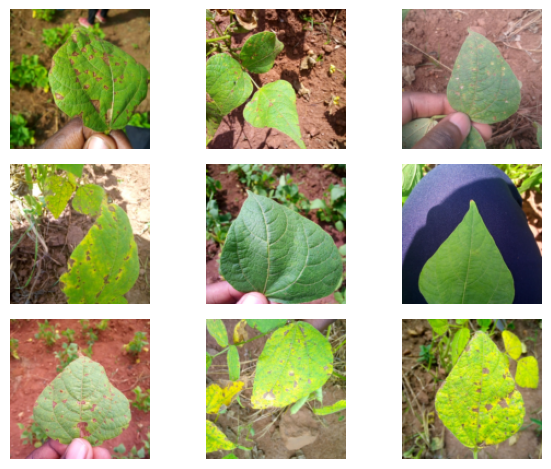

In [15]:
n_rows = 3
n_cols = 3

fig, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
    axarr[row, col].imshow((image * 255.0).squeeze().permute(1, 2, 0))
    axarr[row, col].axis('off')

plt.tight_layout()
plt.show()

In [16]:
BATCH_SIZE = 4
LR = 0.003

In [17]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [18]:
googlenet_model = models.googlenet(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 190MB/s]


In [19]:
for param in googlenet_model.parameters():
  param.requires_grad = True

In [20]:
# Check the last layer
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [21]:
num_classed = len(train_df['category'].unique())
num_classed

3

In [22]:
# Modify Last Layer of pretrained model
googlenet_model.fc = torch.nn.Linear(
    in_features=googlenet_model.fc.in_features,
    out_features=num_classed
)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [23]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [24]:
# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    googlenet_model.parameters(),
    lr = LR
)

In [25]:
# Training loop
EPOCHS = 10

train_loss_per_epoch = []
val_loss_per_epoch = []
train_acc_per_epoch = []
val_acc_per_epoch = []

for epoch in range(EPOCHS):
  train_loss_total = 0
  val_loss_total = 0
  train_acc_total = 0
  val_acc_total = 0

  # Model in Training Mode
  googlenet_model.train()
  for x, y in train_dataloader:

    # Forward Pass
    predictions = googlenet_model(x)

    # Calculate the loss and Acc
    batch_loss = criterion(predictions, y)
    train_loss_total += batch_loss.item()
    batch_acc = (predictions.argmax(dim=1) == y).sum().item()
    train_acc_total += batch_acc

    # Optimizer Zero Grad
    optimizer.zero_grad()

    # Backward Pass
    batch_loss.backward()

    # Optimizer Step
    optimizer.step()

  # Model in Evaluation Mode
  with torch.inference_mode():
    googlenet_model.eval()
    for x, y in val_dataloader:

      # Forward Pass
      predictions = googlenet_model(x)

      # Calculation of validation loss and acc
      batch_loss = criterion(predictions, y)
      val_loss_total += batch_loss.item()
      batch_acc = (predictions.argmax(dim=1) == y).sum().item()
      val_acc_total += batch_acc

    train_loss_per_epoch.append(train_loss_total/len(train_dataloader))
    val_loss_per_epoch.append(val_loss_total/len(val_dataloader))
    train_acc_per_epoch.append((train_acc_total/len(train_dataset)) * 100)
    val_acc_per_epoch.append((val_acc_total/len(val_dataset)) * 100)

    if (epoch+1) % 1 == 0:
      print(f"Epoch: {epoch+1} | Train Loss: {train_loss_total/len(train_dataloader):.4f} | Val Loss: {val_loss_total/len(val_dataloader):.4f} | Train Acc: {train_acc_total/len(train_dataset):.4f} | Val Acc: {val_acc_total/len(val_dataset):.4f}")

Epoch: 1 | Train Loss: 1.1406 | Val Loss: 1.1612 | Train Acc: 0.4159 | Val Acc: 0.3383
Epoch: 2 | Train Loss: 1.0027 | Val Loss: 2.5597 | Train Acc: 0.4952 | Val Acc: 0.3308
Epoch: 3 | Train Loss: 0.9616 | Val Loss: 9.6668 | Train Acc: 0.5174 | Val Acc: 0.3308
Epoch: 4 | Train Loss: 0.8761 | Val Loss: 12.3218 | Train Acc: 0.5735 | Val Acc: 0.3308
Epoch: 5 | Train Loss: 0.8656 | Val Loss: 31.2247 | Train Acc: 0.6044 | Val Acc: 0.3308
Epoch: 6 | Train Loss: 0.7753 | Val Loss: 4.7136 | Train Acc: 0.6605 | Val Acc: 0.3308
Epoch: 7 | Train Loss: 0.7653 | Val Loss: 3.1776 | Train Acc: 0.6789 | Val Acc: 0.3910
Epoch: 8 | Train Loss: 0.7460 | Val Loss: 4.5582 | Train Acc: 0.6867 | Val Acc: 0.3308
Epoch: 9 | Train Loss: 0.6531 | Val Loss: 4.6320 | Train Acc: 0.7205 | Val Acc: 0.3383
Epoch: 10 | Train Loss: 0.6875 | Val Loss: 11.8095 | Train Acc: 0.7195 | Val Acc: 0.3308


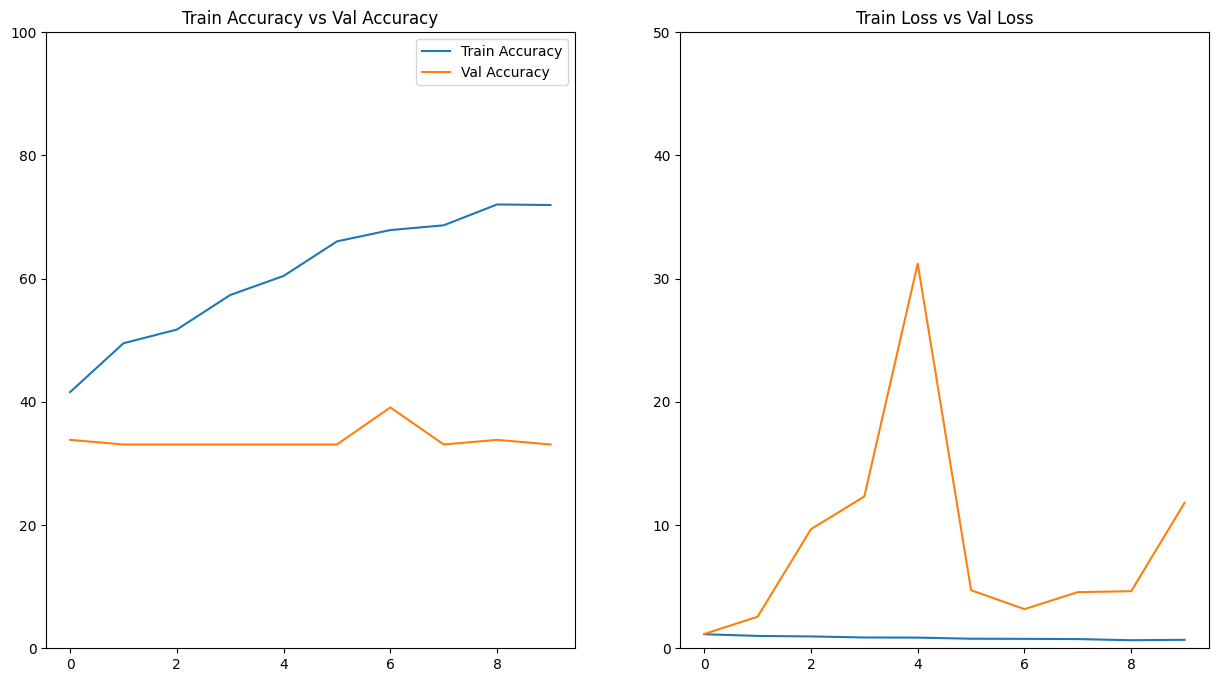

In [28]:
# Plot Train Accuracy vs Val Accuracy and Train Loss vs Val Loss
fig, axs = plt.subplots(1, 2, figsize=(15,8))
axs[0].plot(train_acc_per_epoch, label="Train Accuracy")
axs[0].plot(val_acc_per_epoch, label="Val Accuracy")
axs[0].set_title("Train Accuracy vs Val Accuracy")
axs[0].set_ylim(0, 100)
axs[0].legend()

axs[1].plot(train_loss_per_epoch, label="Train Loss")
axs[1].plot(val_loss_per_epoch, label="Val Loss")
axs[1].set_title("Train Loss vs Val Loss")
axs[1].set_ylim(0, 50)
axs[1].legend

plt.show()
